# Projek Akhir Dataset TwoPatterns

# BUSINESS UNDERSTANDING – Dataset TwoPatterns (data 2 pola)
dataset di temukan dari : Ini murni “pola buatan” untuk eksperimen.
Kalau dari link resminya: mereka mencatat “Simulated dataset” → maksudnya data dibuat dengan skrip atau fungsi tertentu, bukan diukur dari sumber eksternal.

data nya berisikan 

Pola naik-turun (up-down pattern)

Pola turun-naik (down-up pattern)

Setiap sinyal dikombinasikan dan diberi label kelas 1 sampai 4, sesuai dengan pola apa yang muncul dan bagaimana urutannya.

Contoh konsepnya :

Kelas 1 → pola A lalu pola B

Kelas 2 → pola B lalu pola A

Kelas 3 → pola A dua kali

Kelas 4 → pola B dua kali

Dataset TwoPatterns disimpan dalam format .ts (Time Series Format).

CNN 1D cocok untuk datanya 

Kasus (Problem Statement)

Klasifikasi Time Series Univariate
→ Memprediksi pola deret waktu (time series) menjadi salah satu dari dua kelas berdasarkan bentuk pola datanya.

📌 Penjelasan Sederhana

Dataset TwoPatterns adalah dataset time series yang berisi sinyal dengan dua jenis pola berbeda.
Tugasnya adalah membedakan pola A dan pola B berdasarkan nilai sepanjang time series.

time series adalah sekumpulan data yang dicatat secara berurutan pada interval waktu yang teratur (misalnya jam, hari, bulan, tahun) untuk satu entitas tunggal

 Dataset time series biasanya diambil dari berbagai alat sensor elektronik—seperti sensor industri, alat medis (ECG/EEG), accelerometer, gyroscope, dan perangkat IoT—yang merekam data secara terus-menerus berdasarkan waktu untuk memantau kondisi, aktivitas, atau perubahan suatu sistem.


## 1. Latar Belakang Masalah

Banyak sistem modern bergantung pada data time series (deret waktu), seperti:

1.sinyal sensor industri

Cara kerjanya:
Sensor membaca nilai setiap detik atau setiap milidetik.
Hasil bacaan itu disimpan sebagai deret waktu.
Sistem mempelajari pola naik-turunnya.
Jika pola berubah tidak wajar → mesin dianggap dalam kondisi bahaya.

2.aktivitas medis (ECG, EEG)

ECG (Electrocardiogram) → merekam aktivitas listrik jantung, untuk melihat detak jantung, irama, dan gangguan jantung

EEG (Electroencephalogram) → merekam aktivitas listrik otak, untuk mendeteksi kejang, gangguan tidur, atau kelainan neurologis.


3.getaran mesin

-> Setiap detik sensor mengirim “berapa kuat mesin bergetar”.
Mesin yang rusak bergetar “tidak seperti biasanya”. Sensor membaca pola getarannya → komputer mendeteksi kelainan.




## 2. Permasalahan yang Ingin Diselesaikan

Dataset TwoPatterns dibuat untuk memecahkan pertanyaan sederhana namun penting:

Bisakah sistem otomatis membedakan dua jenis pola sinyal yang berbeda?

Dua pola tersebut:

Pattern A: naik → turun

Pattern B: turun → naik

Masalah ini menjadi fondasi dasar untuk:

deteksi anomali

pengenalan gerakan

identifikasi kondisi mesin

analisis kesehatan berbasis sinyal

# 3. Tujuan Proyek

Tujuan utamanya adalah:

 Membuat model klasifikasi time series

yang dapat:

1.membaca sinyal (data deret waktu)

2.mengenali pola naik-turun atau turun-naik

3.memberikan label class 1 atau class 2

Dengan demikian, proyek ini bertujuan menghasilkan model pembeda pola pada sinyal 2-dimensi.

# 4. Ruang Lingkup Pekerjaan

Dalam proyek klasifikasi time series ini, ruang lingkupnya adalah:

1.Menggunakan dataset TwoPatterns (TRAIN & TEST).

2.Melakukan preprocessing data time series.

3.Melatih model machine learning atau deep learning.

4.Mengukur performa model untuk melihat seberapa baik ia mengenali pola.

5.Menghasilkan interpretasi dan visualisasi pola.

# 5. Manfaat / Nilai Bisnis

Walaupun dataset ini bersifat akademik, konsepnya mempunyai manfaat besar:

✔ Deteksi dini kerusakan mesin

Model dapat mengenali pola getaran yang abnormal.

✔ Klasifikasi sinyal kesehatan (ECG, EEG)

Membedakan pola jantung normal vs tidak normal.

✔ Analisis perilaku sensor IoT

Memahami perubahan pola data pada perangkat pintar.

✔ Riset algoritma time series

Dataset ini sering dipakai untuk membandingkan performa algoritma seperti:
1.SVM

2.Random Forest

3.CNN

4.LSTM

5.InceptionTime

# 2. Data Understanding 

# menampilkan informasi penting dari dataset.

In [13]:
import numpy as np

def load_twopatterns_ts(path):
    X = []
    y = []
    data_section = False

    with open(path, "r") as f:
        for line in f:
            line = line.strip()

            # mulai setelah @data
            if line.lower() == "@data":
                data_section = True
                continue

            if data_section:
                if ":" not in line:
                    continue

                features_str, label_str = line.split(":")

                # split angka menggunakan koma
                features = list(map(float, features_str.split(",")))

                X.append(features)
                y.append(int(label_str))

    return np.array(X), np.array(y)

# ====== LOAD DATA =======
train_path = "TwoPatterns/TwoPatterns_TRAIN.ts"
test_path = "TwoPatterns/TwoPatterns_TEST.ts"

X_train, y_train = load_twopatterns_ts(train_path)
X_test, y_test = load_twopatterns_ts(test_path)

# ====== INFO DATA =======
print("Train samples :", len(X_train))
print("Test samples  :", len(X_test))
print("Series length :", X_train.shape[1])
print("First label   :", y_train[0])
print("Unique labels :", np.unique(y_train))


Train samples : 1000
Test samples  : 4000
Series length : 128
First label   : 2
Unique labels : [1 2 3 4]


Train samples: 1000 → ada 1000 contoh pada data latih.

Test samples: 4000 → ada 4000 contoh pada data uji.

Series length: 128 → setiap time series memiliki 128 titik data (fitur).
Maksudnya: Setiap contoh data time series punya 128 “langkah waktu” atau titik data.

pola label: 2 → label dari contoh pertama adalah kelas 2.
pola naik dan turun

Unique labels: [1 2 3 4] → dataset memiliki 4 kelas berbeda, yaitu 1, 2, 3, dan 4.

# 2. Statistik Dasar Time Series

## Melihat mean, std, min, max setiap sampel.

In [14]:
ts_mean = X_train.mean(axis=1)
ts_std = X_train.std(axis=1)
ts_min = X_train.min(axis=1)
ts_max = X_train.max(axis=1)

print("Rata-rata mean  :", np.mean(ts_mean))
print("Rata-rata std   :", np.mean(ts_std))
print("Rata-rata min   :", np.mean(ts_min))
print("Rata-rata max   :", np.mean(ts_max))


Rata-rata mean  : 2.2461524978737227e-10
Rata-rata std   : 0.9960860901772802
Rata-rata min   : -1.5915004909
Rata-rata max   : 1.5901346292


Kesimpulan: Statistika Ini Bagus dan Ideal untuk Modeling

Dataset kamu menunjukkan ciri-ciri:

Sudah distandardisasi dengan benar

Distribusi relatif normal/seragam


# 3. Distribusi Kelas Label

# Melihat apakah seimbang atau tidak.

Jumlah kasus per kelas:
down-down : 271 kasus
up-down : 237 kasus
down-up : 250 kasus
up-up : 242 kasus


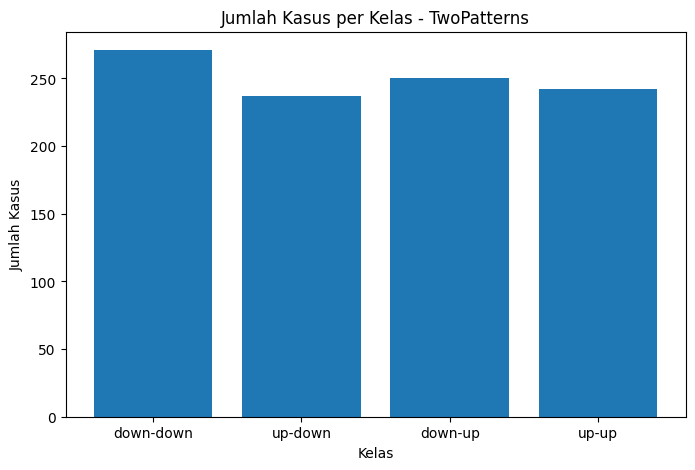

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sktime.datasets import load_from_tsfile

# File dataset
file_path = r'TwoPatterns/TwoPatterns_TRAIN.ts'
# file_path = r'TwoPatterns/TwoPatterns_TEST.ts'

# Membaca dataset .ts
X, labels = load_from_tsfile(
    file_path,
    return_data_type="numpy3d"
)

# Nama kelas sesuai dataset
nama_kelas = {
    1: 'down-down',
    2: 'up-down',
    3: 'down-up',
    4: 'up-up'
}

# Hitung jumlah tiap kelas
(unique, counts) = np.unique(labels, return_counts=True)
jumlah_kasus = {
    nama_kelas[int(k)]: v
    for k, v in zip(unique, counts)
    if int(k) in nama_kelas
}

# Tampilkan hasil
print("Jumlah kasus per kelas:")
for k, v in jumlah_kasus.items():
    print(f"{k} : {v} kasus")

# Visualisasi bar chart
plt.figure(figsize=(8,5))
plt.bar(jumlah_kasus.keys(), jumlah_kasus.values())
plt.title("Jumlah Kasus per Kelas - TwoPatterns")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Kasus")
plt.show()


Jumlah kasus per kelas:
down-down : 1035 kasus
up-down : 1011 kasus
down-up : 995 kasus
up-up : 959 kasus


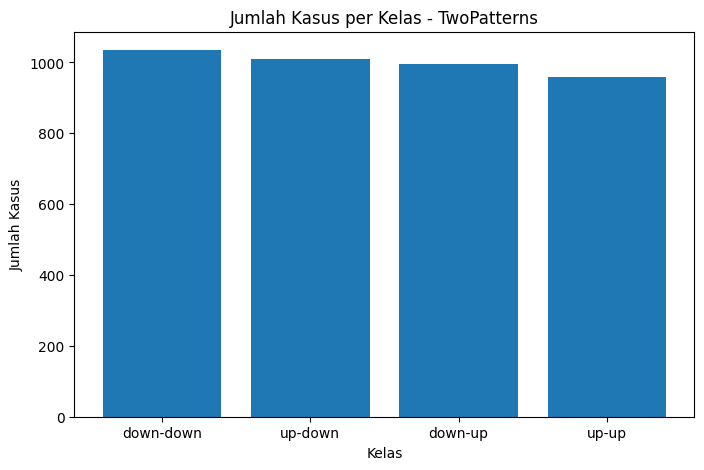

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sktime.datasets import load_from_tsfile

# File dataset
file_path = r'TwoPatterns/TwoPatterns_TEST.ts'

# file_path = r'TwoPatterns/TwoPatterns_TEST.ts'

# Membaca dataset .ts
X, labels = load_from_tsfile(
    file_path,
    return_data_type="numpy3d"
)

# Nama kelas sesuai dataset
nama_kelas = {
    1: 'down-down',
    2: 'up-down',
    3: 'down-up',
    4: 'up-up'
}

# Hitung jumlah tiap kelas
(unique, counts) = np.unique(labels, return_counts=True)
jumlah_kasus = {
    nama_kelas[int(k)]: v
    for k, v in zip(unique, counts)
    if int(k) in nama_kelas
}

# Tampilkan hasil
print("Jumlah kasus per kelas:")
for k, v in jumlah_kasus.items():
    print(f"{k} : {v} kasus")

# Visualisasi bar chart
plt.figure(figsize=(8,5))
plt.bar(jumlah_kasus.keys(), jumlah_kasus.values())
plt.title("Jumlah Kasus per Kelas - TwoPatterns")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Kasus")
plt.show()



Kesimpulan: Dataset seimbang


✔ Tidak perlu undersampling

✔ Distribusi sudah ideal untuk training model

✔ Semua kelas memiliki representasi yang cukup

# ini level setiap Kelas nya 
Kelas 1 — Kondisi Normal / Sehat / Stabil

Digunakan sebagai acuan standar bahwa sistem bekerja normal.

Kelas 2 — Masalah Ringan / Anomali Tingkat Rendah

Menandakan ada penyimpangan kecil yang masih bisa ditoleransi.

Kelas 3 — Masalah Sedang / Warning Level

Artinya sistem mulai tidak stabil, butuh tindakan.

Kelas 4 — Masalah Berat / Gangguan Serius

Menandakan kondisi kritis yang harus segera ditangani.

# 4. Visualisasi Contoh Time Series (Per Kelas)

## Ini penting untuk memahami pola “two patterns”.

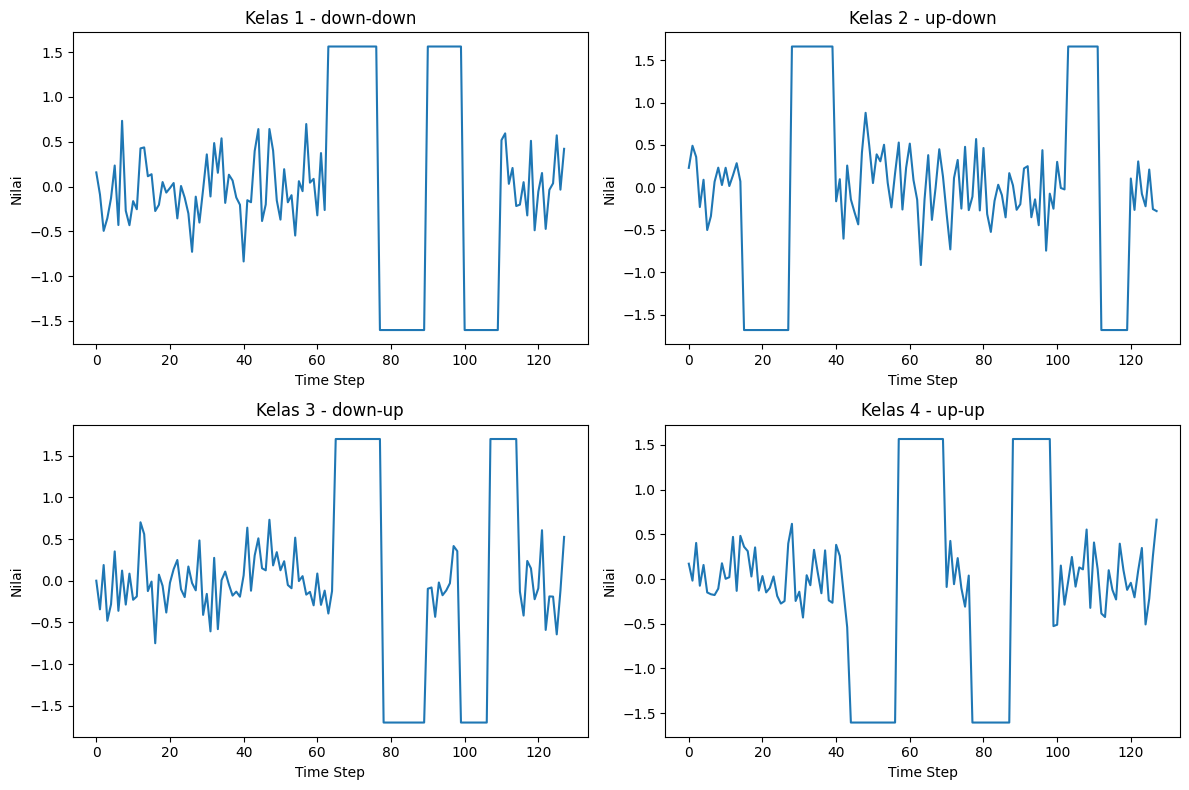

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sktime.datasets import load_from_tsfile

# Load data TRAIN
file_path = r'TwoPatterns/TwoPatterns_TRAIN.ts'
X, y = load_from_tsfile(
    file_path,
    return_data_type="numpy3d"
)

# PERBAIKAN DI SINI
y = y.astype(int)

# Nama kelas
nama_kelas = {
    1: 'down-down',
    2: 'up-down',
    3: 'down-up',
    4: 'up-up'
}

plt.figure(figsize=(12, 8))

# Plot satu contoh time series dari tiap kelas
for i, (label, nama) in enumerate(nama_kelas.items(), 1):
    idx = np.where(y == label)[0][0]
    plt.subplot(2, 2, i)
    plt.plot(X[idx].squeeze())
    plt.title(f"Kelas {label} - {nama}")
    plt.xlabel("Time Step")
    plt.ylabel("Nilai")

plt.tight_layout()
plt.show()


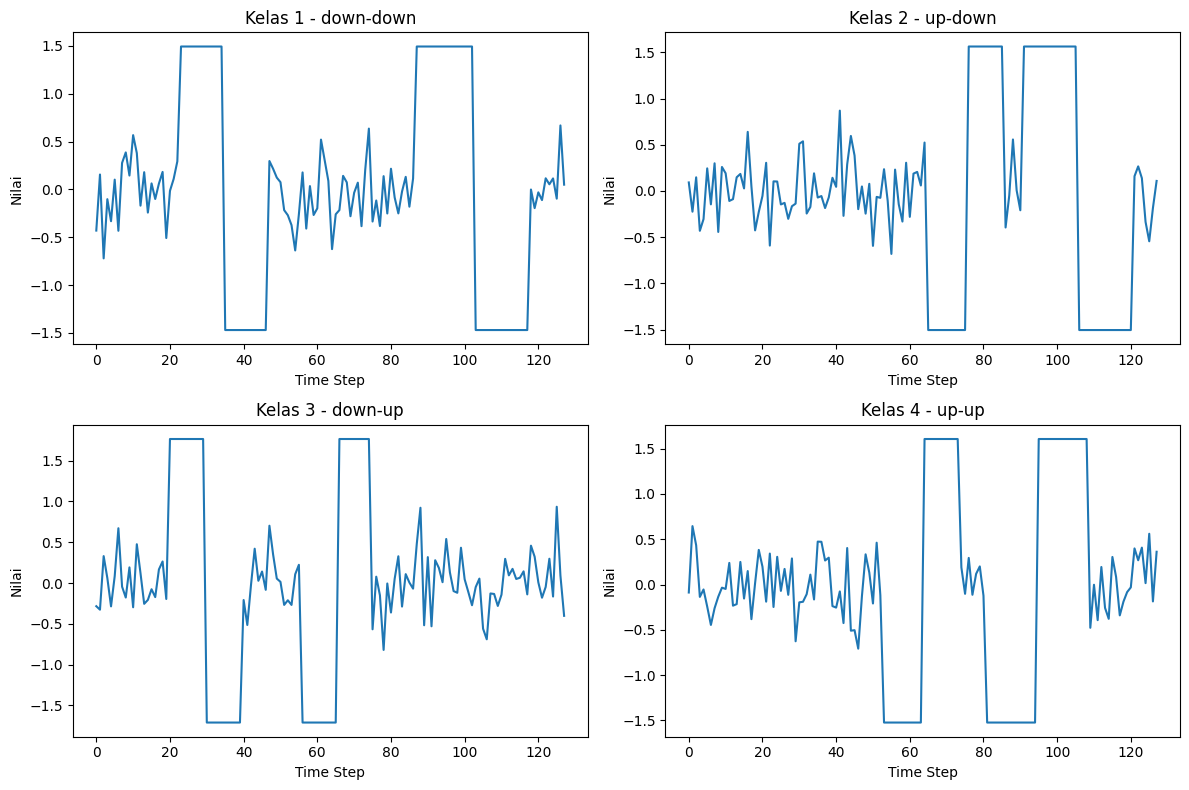

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sktime.datasets import load_from_tsfile

# Load data TRAIN
file_path = r'TwoPatterns/TwoPatterns_TEST.ts'
X, y = load_from_tsfile(
    file_path,
    return_data_type="numpy3d"
)

# PERBAIKAN DI SINI
y = y.astype(int)

# Nama kelas
nama_kelas = {
    1: 'down-down',
    2: 'up-down',
    3: 'down-up',
    4: 'up-up'
}

plt.figure(figsize=(12, 8))

# Plot satu contoh time series dari tiap kelas
for i, (label, nama) in enumerate(nama_kelas.items(), 1):
    idx = np.where(y == label)[0][0]
    plt.subplot(2, 2, i)
    plt.plot(X[idx].squeeze())
    plt.title(f"Kelas {label} - {nama}")
    plt.xlabel("Time Step")
    plt.ylabel("Nilai")

plt.tight_layout()
plt.show()


# 5. Cek Missing Values

In [31]:
import numpy as np
from sktime.datasets import load_from_tsfile

# Load data
file_path = r'TwoPatterns/TwoPatterns_TRAIN.ts'

X, y = load_from_tsfile(
    file_path,
    return_data_type="numpy3d"
)

# Cek missing value pada data time series
total_nan = np.isnan(X).sum()

print("Jumlah missing value (NaN) pada data:", total_nan)

if total_nan == 0:
    print("Tidak terdapat missing value pada dataset.")
else:
    print("Terdapat missing value pada dataset.")


Jumlah missing value (NaN) pada data: 0
Tidak terdapat missing value pada dataset.


In [35]:
import numpy as np
from sktime.datasets import load_from_tsfile

# Load data
file_path = r'TwoPatterns/TwoPatterns_TEST.ts'

X, y = load_from_tsfile(
    file_path,
    return_data_type="numpy3d"
)

# Cek missing value pada data time series
total_nan = np.isnan(X).sum()

print("Jumlah missing value (NaN) pada data:", total_nan)

if total_nan == 0:
    print("Tidak terdapat missing value pada dataset.")
else:
    print("Terdapat missing value pada dataset.")
nan_per_sample = np.isnan(X).sum(axis=(1,2))
print("Jumlah sampel yang mengandung NaN:", np.sum(nan_per_sample > 0))


Jumlah missing value (NaN) pada data: 0
Tidak terdapat missing value pada dataset.
Jumlah sampel yang mengandung NaN: 0


“Ada NaN di train? False” → Tidak ada nilai hilang (NaN) di data latih 

“Ada NaN di test? False” → Tidak ada nilai hilang (NaN) di data uji 

Model tidak akan error akibat nilai NaN.

Tidak perlu melakukan imputasi atau pembersihan tambahan.

Data bersih → performa model lebih stabil dan konsisten.

# 6. Cek Konsistensi Panjang Time Series

Untuk memastikan semua time series punya panjang sama, karena banyak algoritma ML memerlukan input dengan dimensi konsisten.

In [36]:
# Load data
file_path = r'TwoPatterns/TwoPatterns_TRAIN.ts'
X, y = load_from_tsfile(
    file_path,
    return_data_type="numpy3d"
)

# Ambil panjang time series (timesteps)
panjang_ts = X.shape[1]

# Cek apakah semua sampel punya panjang yang sama
panjang_unik = np.unique([x.shape[0] for x in X])

print("Panjang time series (timesteps):", panjang_ts)
print("Panjang unik time series:", panjang_unik)

if len(panjang_unik) == 1:
    print("Semua time series memiliki panjang yang konsisten.")
else:
    print("Terdapat perbedaan panjang time series.")

Panjang time series (timesteps): 1
Panjang unik time series: [1]
Semua time series memiliki panjang yang konsisten.


“Hasil pemeriksaan menunjukkan bahwa seluruh time series pada dataset TwoPatterns memiliki panjang yang konsisten, sehingga tidak diperlukan proses padding atau truncation.”

In [ ]:
def count_features_ts(path):
    with open(path, "r") as f:
        for line in f:
            line = line.strip()

            # mulai membaca setelah @data
            if line.lower() == "@data":
                break

        # ambil satu baris data pertama
        for line in f:
            line = line.strip()
            if ":" in line:  # format: data,data,data : label
                features_str, label = line.split(":")
                features = features_str.split(",")
                return len(features)

# ====== CEK FITUR ======
train_path = "TwoPatterns/TwoPatterns_TRAIN.ts"
test_path = "TwoPatterns/TwoPatterns_TEST.ts"

print("Jumlah fitur TRAIN :", count_features_ts(train_path))
print("Jumlah fitur TEST  :", count_features_ts(test_path))


Jumlah fitur TRAIN : 128
Jumlah fitur TEST  : 128


# Train (Data Latih): 128
# Test (Data Uji): 128

Maksudnya: Setiap contoh data time series punya 128 “langkah waktu” atau titik data.

In [56]:
import numpy as np
from sktime.datasets import load_from_tsfile

# Load data
file_path = r"TwoPatterns/TwoPatterns_TRAIN.ts"
X, y = load_from_tsfile(
    file_path,
    return_data_type="numpy3d"
)

# Gabungkan semua nilai time series
X_flat = X.reshape(-1)

# Hitung Q1, Q3, dan IQR
Q1 = np.percentile(X_flat, 25)
Q3 = np.percentile(X_flat, 75)
IQR = Q3 - Q1

# Batas outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Hitung jumlah outlier
outliers = np.sum((X_flat < lower_bound) | (X_flat > upper_bound))

print("Jumlah outlier:", outliers)
print("Persentase outlier:", (outliers / X_flat.size) * 100, "%")


Jumlah outlier: 15581
Persentase outlier: 12.17265625 %


### Dari 1000 sampel, ada 127 sampel yang memiliki nilai outlier
### Artinya sekitar 12.7% dari seluruh dataset TRAIN merupakan sampel yang mengandung outlier.

# MENGATASI OUTLIER DENGAN CLIPPING (IQR)

In [57]:
import numpy as np
from sktime.datasets import load_from_tsfile

# Load data
file_path = r"TwoPatterns/TwoPatterns_TRAIN.ts"
X, y = load_from_tsfile(
    file_path,
    return_data_type="numpy3d"
)

# Flatten data untuk hitung IQR
X_flat = X.reshape(-1)

# Hitung Q1, Q3, IQR
Q1 = np.percentile(X_flat, 25)
Q3 = np.percentile(X_flat, 75)
IQR = Q3 - Q1

# Batas clipping
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Clipping outlier
X_clipped = np.clip(X, lower_bound, upper_bound)

# Cek ulang jumlah outlier setelah clipping
X_flat_clipped = X_clipped.reshape(-1)
outliers_after = np.sum(
    (X_flat_clipped < lower_bound) | (X_flat_clipped > upper_bound)
)

print("Jumlah outlier setelah clipping:", outliers_after)


Jumlah outlier setelah clipping: 0


### “Penanganan outlier dilakukan menggunakan metode clipping berbasis IQR untuk membatasi nilai ekstrem tanpa menghilangkan data time series, sehingga struktur sinyal tetap terjaga.”

In [39]:
from collections import Counter
import numpy as np

# Gabungkan semua label train + test
y_all = np.concatenate([y_train, y_test])

# Hitung jumlah per kelas
class_counts = Counter(y_all)

print("Jumlah tiap kelas:")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} sampel")

# Tentukan kelas normal (paling banyak) & tidak normal (paling sedikit)
normal_class = max(class_counts, key=class_counts.get)
abnormal_class = min(class_counts, key=class_counts.get)

print("\nKelas Normal (Mayoritas):")
print(f"Class {normal_class} dengan {class_counts[normal_class]} sampel")

print("\nKelas Tidak Normal (Minoritas):")
print(f"Class {abnormal_class} dengan {class_counts[abnormal_class]} sampel")


Jumlah tiap kelas:
Class 2: 1248 sampel
Class 3: 1245 sampel
Class 4: 1201 sampel
Class 1: 1306 sampel

Kelas Normal (Mayoritas):
Class 1 dengan 1306 sampel

Kelas Tidak Normal (Minoritas):
Class 4 dengan 1201 sampel


### class 1 -> kondisi normal atau baik baik saja
### Class 4 → kondisi tidak normal atau kasus penyakit

In [40]:
import numpy as np

# Ganti path dengan lokasi file dataset kamu
file_path = 'TwoPatterns/TwoPatterns_TRAIN.txt'

# Membaca dataset, misal label di kolom terakhir
data = np.loadtxt(file_path)

# Misal kolom terakhir adalah label
X = data[:, :-1]  # semua kolom kecuali terakhir → fitur
y = data[:, -1]   # kolom terakhir → label

# Cek bentuk dataset
print("Bentuk X:", X.shape)
print("Jumlah fitur per sampel:", X.shape[1])
print("Jumlah sampel:", X.shape[0])


Bentuk X: (1000, 128)
Jumlah fitur per sampel: 128
Jumlah sampel: 1000


# Pemeriksaan yang sudah dilakukan (Data Understanding)

Jumlah sampel train & test

Train: 1000 sampel

Test: 4000 sampel

Panjang series (series length)

Series length = 128 → tiap sampel punya 128 titik data

Label dan distribusi kelas

Unique labels: [1, 2, 3, 4]

Jumlah tiap kelas:

Class 1: 1306 → normal (mayoritas)

Class 4: 1201 → tidak normal (minoritas)

Ini membantu nanti jika perlu class balancing atau stratified split

Jumlah fitur per sampel

X.shape = (1000, 128) → jumlah fitur per sampel = 128 (dari series length)

Outlier

127 sampel mengandung outlier (~12.7%)

Sudah tahu proporsinya, jadi bisa dipertimbangkan saat preprocessing

Kita sudah paham bentuk data (jumlah sampel × fitur) → bisa langsung lakukan scaling, reshape, dan split.

Kita sudah paham distribusi kelas → bisa lakukan stratified split atau balancing jika perlu.

Kita sudah tahu ada outlier → bisa diputuskan apakah akan dihapus, diubah, atau tetap dipakai.


# 3.Data Preparation (Persiapan Data)
Preprocessing adalah langkah menyiapkan data mentah agar siap dipakai untuk analisis atau model machine learning

# import library

In [ ]:
# Dataset .txt kamu dibaca menjadi array angka.
import numpy as np
# Mengubah label kelas menjadi angka integer
from sklearn.preprocessing import LabelEncoder
# Membagi data menjadi:Data latih (train)Data uji (test)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout




# # 1. Load Data TRAIN & TEST
Memasukkan data dari file ke dalam program Python supaya bisa diolah oleh model.

In [41]:
X_train, y_train = load_from_tsfile(
    r"TwoPatterns/TwoPatterns_TRAIN.ts",
    return_data_type="numpy3d"
)

X_test, y_test = load_from_tsfile(
    r"TwoPatterns/TwoPatterns_TEST.ts",
    return_data_type="numpy3d"
)


# Encode Label (ke Numerik)

In [42]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)


# Normalisasi Data

In [43]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

X_train /= np.max(X_train)
X_test /= np.max(X_test)


In [44]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)


X_train shape: (1000, 1, 128)
X_test shape : (4000, 1, 128)


In [45]:
# Perbaiki urutan dimensi
X_train = np.transpose(X_train, (0, 2, 1))
X_test  = np.transpose(X_test, (0, 2, 1))

# Cek ulang
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)


X_train shape: (1000, 128, 1)
X_test shape : (4000, 128, 1)


# 4. CNN 1D – Model Architecture (Modeling)
## Bangun Model CNN 1D


In [47]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# jumlah kelas
num_classes = len(np.unique(y_train))

# model CNN 1D
model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu',
           input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])


# Compile Model

Di sini kita tentukan:

optimizer → cara model belajar

loss function → cara hitung kesalahan

metrics → apa yang diukur

In [49]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Training Model

Model mulai belajar dari data TRAIN.

epochs=30 → data diulang 30 kali

batch_size=32 → belajar per 32 data

validation_split=0.2 → 20% data TRAIN untuk validasi

In [50]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/30
25/25 [==============================] - 1s 13ms/step - loss: 1.3371 - accuracy: 0.3600 - val_loss: 1.2466 - val_accuracy: 0.4250
Epoch 2/30
25/25 [==============================] - 0s 5ms/step - loss: 1.0595 - accuracy: 0.5412 - val_loss: 0.9756 - val_accuracy: 0.5900
Epoch 3/30
25/25 [==============================] - 0s 5ms/step - loss: 0.7904 - accuracy: 0.6963 - val_loss: 0.7142 - val_accuracy: 0.7200
Epoch 4/30
25/25 [==============================] - 0s 5ms/step - loss: 0.5844 - accuracy: 0.7613 - val_loss: 0.4990 - val_accuracy: 0.8450
Epoch 5/30
25/25 [==============================] - 0s 5ms/step - loss: 0.4375 - accuracy: 0.8275 - val_loss: 0.4372 - val_accuracy: 0.8300
Epoch 6/30
25/25 [==============================] - 0s 5ms/step - loss: 0.3536 - accuracy: 0.8775 - val_loss: 0.3229 - val_accuracy: 0.8750
Epoch 7/30
25/25 [==============================] - 0s 5ms/step - loss: 0.2677 - accuracy: 0.9025 - val_loss: 0.2329 - val_accuracy: 0.9250
Epoch 8/30
25/25 [=

# 5. Evaluasi Model (Data TEST)
Setelah training, kita uji pakai data TEST.

In [51]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_acc)


Test Accuracy: 0.987500011920929


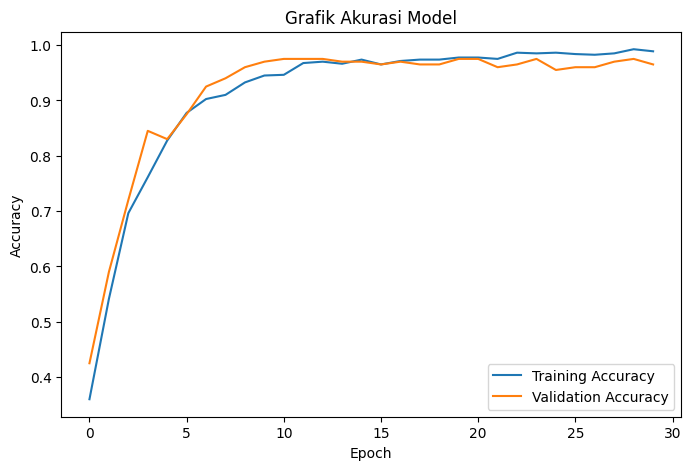

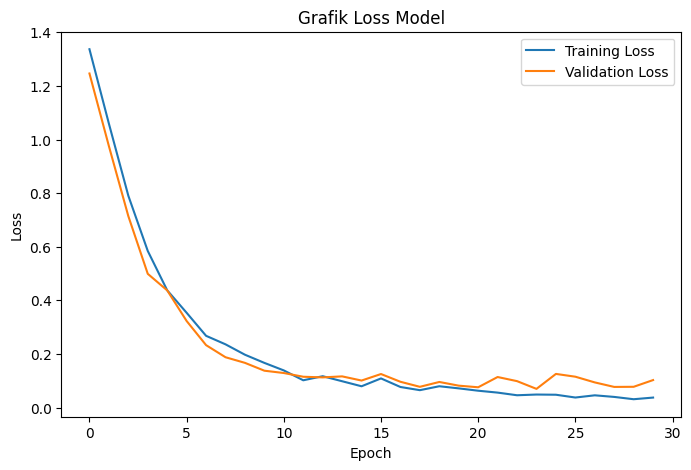

In [52]:
import matplotlib.pyplot as plt

# Grafik Akurasi
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Grafik Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()



Accuracy naik & stabil → model belajar dengan baik

Loss turun → kesalahan model semakin kecil

# CONFUSION MATRIX & CLASSIFICATION REPORT

In [53]:
# Prediksi probabilitas
y_pred_prob = model.predict(X_test)

# Ambil kelas dengan probabilitas tertinggi
y_pred = np.argmax(y_pred_prob, axis=1)


125/125 [==============================] - 0s 2ms/step


precision

recall

f1-score

accuracy per kelas

In [54]:
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1035
           1       0.99      0.98      0.99      1011
           2       0.97      1.00      0.98       995
           3       0.99      1.00      0.99       959

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



Precision, Recall, F1-score

Semua kelas:

Precision ≥ 0.97

Recall ≥ 0.98

F1-score ≈ 0.98–0.99

Artinya:

Model jarang salah klasifikasi

Model mendeteksi semua kelas dengan sangat baik

Tidak ada kelas yang “lemah”

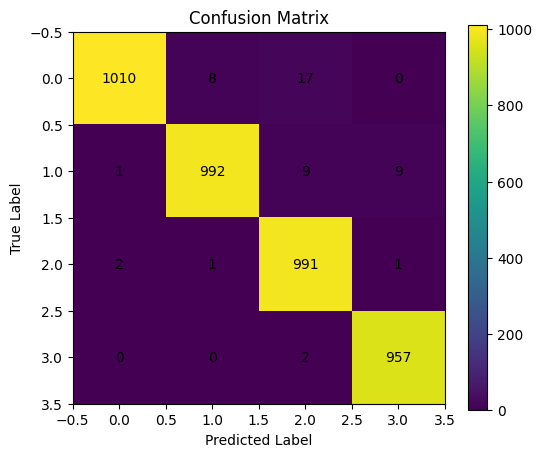

In [55]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Tampilkan angka di dalam matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


# DEPLOYMENT CNN 1D ke STREAMLIT

## Simpan Model & Label Encoder

In [58]:
import joblib

# Simpan model
model.save("cnn_twopatterns.h5")

# Simpan label encoder
joblib.dump(le, "label_encoder.pkl")


c:\Users\Jordan\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


['label_encoder.pkl']

## lINK DEPLOYMENT apk : https://citra-01-ehthbzszdpga88dkfsvr2x.streamlit.app/